# KẺ MẠO DANH - EFFICIENTNET-B2 (FULL 100% DATA - 288x288)

Notebook huấn luyện mô hình EfficientNet-B2 (Pretrained) với cơ chế Squeeze-and-Excitation tối ưu trích xuất đặc trưng Deepfake, huấn luyện 10 epochs trên 100% dữ liệu (không crop), tích hợp thanh tiến trình TQDM và Test-Time Augmentation (TTA) trên Private Test.

## 1. Cấu hình

In [1]:
import os

# Phải đặt trước khi torch khởi tạo CUDA.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

from pathlib import Path
import random
import time
import zipfile

import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageOps
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

# Tự động nhận diện DATA_ROOT
if Path("data").exists():
    DATA_ROOT = Path("data")
elif Path("/home/user/TACVU1/data").exists():
    DATA_ROOT = Path("/home/user/TACVU1/data")
else:
    DATA_ROOT = Path(__file__).resolve().parent / "data" if "__file__" in locals() else Path("data")

SPLIT = "private_test"       # Tập kiểm tra Private Test (đã mở khóa pass 225554)

EPOCHS = 10                  # 10 epochs tối ưu thời gian
IMAGE_SIZE = 288             # Độ phân giải chuẩn của EfficientNet-B2 (288x288)
BATCH_SIZE = 32              # Batch size 32
LEARNING_RATE = 5e-5         # Tốc độ học mượt mà
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"[cấu hình] split={SPLIT} | epochs={EPOCHS} | batch={BATCH_SIZE} | ảnh={IMAGE_SIZE}px | lr={LEARNING_RATE} | seed={SEED}")
print(f"[cấu hình] thiết bị: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))
print(f"[cấu hình] DATA_ROOT={DATA_ROOT.resolve()}")

[cấu hình] split=private_test | epochs=10 | batch=32 | ảnh=288px | lr=5e-05 | seed=42
[cấu hình] thiết bị: mps
[cấu hình] DATA_ROOT=/Users/quangmanh/Project/Olympic-AI-Practice-1/tacvu3_deepFake/ca1/TACVU1/data


/Users/quangmanh/Project/Olympic-AI-Practice-1/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Mô hình EfficientNet-B2 và Phép biến đổi ảnh

In [2]:
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

def get_efficientnet_b2(num_classes=2, pretrained=True, dropout=0.3):
    """Khởi tạo EfficientNet-B2 pretrained và thay classification head 2 classes."""
    weights = EfficientNet_B2_Weights.DEFAULT if pretrained else None
    model = efficientnet_b2(weights=weights)
    in_features = model.classifier[1].in_features  # 1408
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, num_classes)
    )
    return model


normalize = transforms.Normalize((.485, .456, .406), (.229, .224, .225))

# Augmentation độ phân giải 288x288 (Không crop, giữ nguyên 100% biên mặt và nền)
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    normalize,
])

eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    normalize,
])

model = get_efficientnet_b2(num_classes=2, pretrained=True, dropout=0.3).to(DEVICE)
print(f"[mô hình] EfficientNet-B2: {sum(p.numel() for p in model.parameters()):,} tham số")

[mô hình] EfficientNet-B2: 7,703,812 tham số


## 3. Dataset

In [3]:
def load_image(path: Path, tf):
    with Image.open(path) as image:
        return tf(ImageOps.exif_transpose(image).convert('RGB'))


class SingleImages(Dataset):
    """Tách mỗi cặp thành hai mẫu ảnh đơn kèm nhãn thật (0) / giả (1)."""

    def __init__(self, pairs, tf, folder='train'):
        self.tf = tf
        self.folder = folder
        self.rows = []
        for row in pairs.itertuples(index=False):
            # row.fake_position == 0 -> image_0 là Fake (1), image_1 là Real (0)
            self.rows.append((row.image_0, int(row.fake_position == 0)))
            self.rows.append((row.image_1, int(row.fake_position == 1)))

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        relative, label = self.rows[index]
        return load_image(DATA_ROOT / self.folder / relative, self.tf), label


class ImagePairs(Dataset):
    """Trả về cả hai ảnh của một cặp để so sánh khi dự đoán hoặc đánh giá validation."""

    def __init__(self, pairs, split_dir=SPLIT, has_labels=False):
        self.pairs = pairs.reset_index(drop=True)
        self.split_dir = split_dir
        self.has_labels = has_labels

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        row = self.pairs.iloc[index]
        first = load_image(DATA_ROOT / self.split_dir / row.image_0, eval_tf)
        second = load_image(DATA_ROOT / self.split_dir / row.image_1, eval_tf)
        if self.has_labels:
            return first, second, int(row.fake_position), index
        return first, second, index


print('[dataset] đã định nghĩa SingleImages và ImagePairs hỗ trợ cả Train/Val/Test')

[dataset] đã định nghĩa SingleImages và ImagePairs hỗ trợ cả Train/Val/Test


## 4. Nạp 100% dữ liệu huấn luyện

In [4]:
train_pairs = pd.read_csv(DATA_ROOT / "train" / "pairs.csv", dtype={"pair_id": str})
query = pd.read_csv(DATA_ROOT / SPLIT / "pairs.csv", dtype={"pair_id": str})

# Huấn luyện trên toàn bộ 100% dữ liệu (1,000 cặp = 2,000 ảnh)
train_set = SingleImages(train_pairs, train_tf, folder="train")
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

print(f"[dữ liệu] train: 100% data ({len(train_pairs):,} cặp -> {len(train_set):,} ảnh)")
print(f"[dữ liệu] {SPLIT}: {len(query):,} cặp cần dự đoán")
print(f"[dữ liệu] phân bố nhãn train: {train_pairs.fake_position.value_counts().to_dict()}")

[dữ liệu] train: 100% data (1,000 cặp -> 2,000 ảnh)
[dữ liệu] private_test: 100 cặp cần dự đoán
[dữ liệu] phân bố nhãn train: {1: 500, 0: 500}


## 5. Huấn luyện 15 Epochs với Tốc độ học chậm (AdamW + CosineAnnealingLR)

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

train_losses = []
train_accs = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    started = time.time()
    train_loss_total, train_correct, train_seen = 0.0, 0, 0

    # Thanh tiến trình TQDM cho từng batch trong epoch
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS:02d}", unit="batch", leave=False)
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        batch_sz = labels.size(0)
        train_loss_total += loss.item() * batch_sz
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_seen += batch_sz

        # Cập nhật metric trực tiếp lên thanh tiến trình
        curr_loss = train_loss_total / train_seen
        curr_acc = train_correct / train_seen
        pbar.set_postfix({"loss": f"{curr_loss:.4f}", "acc": f"{curr_acc:.4f}"})

    scheduler.step()
    epoch_train_loss = train_loss_total / train_seen
    epoch_train_acc = train_correct / train_seen
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    curr_lr = optimizer.param_groups[0]["lr"]
    print(f"[huấn luyện] epoch {epoch:02d}/{EPOCHS:02d} | loss={epoch_train_loss:.4f} | accuracy={epoch_train_acc:.4f} | lr={curr_lr:.6f} | {time.time() - started:.1f}s")

torch.save(model.state_dict(), "best_model.pth")
print(f"\n[huấn luyện] Hoàn tất {EPOCHS} epochs! Đã lưu trọng số vào best_model.pth")


[huấn luyện] epoch 01/10 | loss=0.6185 | accuracy=0.6695 | lr=0.000049 | 83.3s


[huấn luyện] epoch 02/10 | loss=0.4511 | accuracy=0.8190 | lr=0.000045 | 80.6s


[huấn luyện] epoch 03/10 | loss=0.3446 | accuracy=0.8910 | lr=0.000040 | 79.7s


[huấn luyện] epoch 04/10 | loss=0.2909 | accuracy=0.9145 | lr=0.000033 | 77.5s


[huấn luyện] epoch 05/10 | loss=0.2403 | accuracy=0.9450 | lr=0.000026 | 78.0s


[huấn luyện] epoch 06/10 | loss=0.2163 | accuracy=0.9575 | lr=0.000018 | 78.2s


[huấn luyện] epoch 07/10 | loss=0.2307 | accuracy=0.9465 | lr=0.000011 | 80.4s


[huấn luyện] epoch 08/10 | loss=0.1948 | accuracy=0.9665 | lr=0.000006 | 80.4s


[huấn luyện] epoch 09/10 | loss=0.2006 | accuracy=0.9665 | lr=0.000002 | 80.5s


[huấn luyện] epoch 10/10 | loss=0.1988 | accuracy=0.9670 | lr=0.000001 | 80.5s

[huấn luyện] Hoàn tất 10 epochs! Đã lưu trọng số vào best_model.pth


## 6. Trực quan hóa Loss & Accuracy Curve

Text(0.5, 1.02, 'Huấn luyện EfficientNet-B2 (288x288, 10 Epochs, No Crop)')

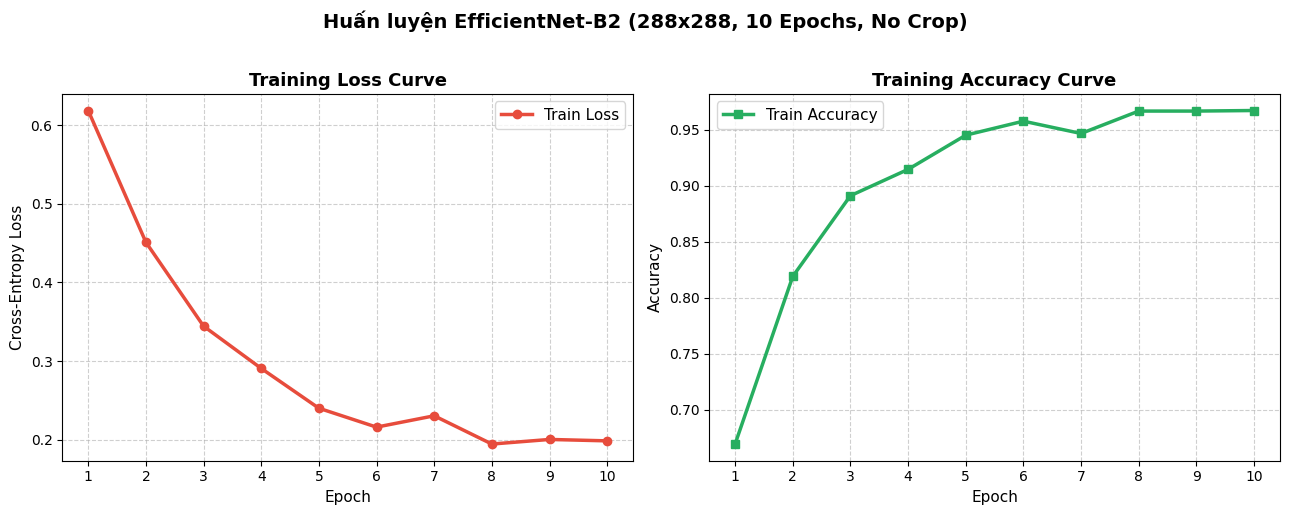

In [6]:
import matplotlib.pyplot as plt

epochs_range = list(range(1, len(train_losses) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 1. Training Loss
ax1.plot(epochs_range, train_losses, "o-", color="#e74c3c", linewidth=2.5, markersize=6, label="Train Loss")
ax1.set_title("Training Loss Curve", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Cross-Entropy Loss", fontsize=11)
ax1.set_xticks(epochs_range)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(fontsize=11)

# 2. Training Accuracy
ax2.plot(epochs_range, train_accs, "s-", color="#27ae60", linewidth=2.5, markersize=6, label="Train Accuracy")
ax2.set_title("Training Accuracy Curve", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Accuracy", fontsize=11)
ax2.set_xticks(epochs_range)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(fontsize=11)

plt.suptitle("Huấn luyện EfficientNet-B2 (288x288, 10 Epochs, No Crop)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.suptitle("Huấn luyện EfficientNet-B2 (288x288, 10 Epochs, No Crop)", fontsize=14, fontweight="bold", y=1.02)


## 7. Dự đoán Private Test (với TTA) và Đóng gói bài nộp

In [7]:
# Nạp trọng số mô hình đã huấn luyện
if os.path.exists("best_model.pth"):
    print("[nạp trọng số] Đang nạp best_model.pth...")
    model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))

model.eval()
predictions = np.zeros(len(query), dtype=np.int64)
started = time.time()

test_loader = DataLoader(ImagePairs(query, split_dir=SPLIT), batch_size=BATCH_SIZE)
with torch.inference_mode():
    for first, second, indices in tqdm(test_loader, desc="Dự đoán Private Test", unit="batch"):
        # Test-Time Augmentation (TTA): Lấy trung bình giữa ảnh gốc và ảnh lật ngang
        first_flipped = torch.flip(first, dims=[3])
        second_flipped = torch.flip(second, dims=[3])

        p0_orig = torch.softmax(model(first.to(DEVICE)), 1)[:, 1]
        p0_flip = torch.softmax(model(first_flipped.to(DEVICE)), 1)[:, 1]
        fake_prob_0 = (p0_orig + p0_flip) / 2.0

        p1_orig = torch.softmax(model(second.to(DEVICE)), 1)[:, 1]
        p1_flip = torch.softmax(model(second_flipped.to(DEVICE)), 1)[:, 1]
        fake_prob_1 = (p1_orig + p1_flip) / 2.0

        predictions[indices.numpy()] = (fake_prob_1 > fake_prob_0).cpu().numpy()

submission = pd.DataFrame({"pair_id": query.pair_id, "fake_position": predictions})
submission.to_csv("submission.csv", index=False)

with zipfile.ZipFile("submission.zip", "w", zipfile.ZIP_DEFLATED) as archive:
    archive.write("submission.csv")

print(f"[dự đoán] {len(submission):,} cặp PRIVATE TEST (sử dụng TTA) trong {time.time() - started:.1f}s")
print(f"[dự đoán] phân bố nhãn: {submission.fake_position.value_counts().to_dict()}")
print("[nộp bài] đã tạo submission.zip (chứa đúng submission.csv ở thư mục gốc)")

[nạp trọng số] Đang nạp best_model.pth...


Dự đoán Private Test: 100%|██████████| 4/4 [00:04<00:00,  1.10s/batch]

[dự đoán] 100 cặp PRIVATE TEST (sử dụng TTA) trong 4.4s
[dự đoán] phân bố nhãn: {1: 50, 0: 50}
[nộp bài] đã tạo submission.zip (chứa đúng submission.csv ở thư mục gốc)
